In [1]:
from PIL import Image
import numpy as np
import torch
import cv2

# 图片路径
image_path_1 = "./datasets/blendedmvs/5b3b353d8d46a939f93524b9/blended_images/00000096.jpg"  # 替换为你的第一张图片路径
image_path_2 = "./datasets/blendedmvs/5b3b353d8d46a939f93524b9/blended_images/00000063.jpg"  # 替换为你的第二张图片路径

# 使用 Pillow 打开图片
img1 = Image.open(image_path_1)
img2 = Image.open(image_path_2)

# 将图片转换为 NumPy 数组
img1_array = np.array(img1)
img2_array = np.array(img2)

img1_torch = torch.from_numpy(img1_array).permute(2,0,1).unsqueeze(0).unsqueeze(0) / 255
img2_torch = torch.from_numpy(img2_array).permute(2,0,1).unsqueeze(0) / 255

# 打印数组形状以确认
print("Image 1 shape:", img1_torch.shape)
print("Image 2 shape:", img2_torch.shape)

Image 1 shape: torch.Size([1, 1, 3, 576, 768])
Image 2 shape: torch.Size([1, 3, 576, 768])


In [2]:
import re
def load_pfm(file):
    color = None
    width = None
    height = None
    scale = None
    data_type = None
    header = file.readline().decode('UTF-8').rstrip()

    if header == 'PF':
        color = True
    elif header == 'Pf':
        color = False
    else:
        raise Exception('Not a PFM file.')
    dim_match = re.match(r'^(\d+)\s(\d+)\s$', file.readline().decode('UTF-8'))
    if dim_match:
        width, height = map(int, dim_match.groups())
    else:
        raise Exception('Malformed PFM header.')
    # scale = float(file.readline().rstrip())
    scale = float((file.readline()).decode('UTF-8').rstrip())
    if scale < 0: # little-endian
        data_type = '<f'
    else:
        data_type = '>f' # big-endian
    data_string = file.read()
    data = np.fromstring(data_string, data_type)
    shape = (height, width, 3) if color else (height, width)
    data = np.reshape(data, shape)
    data = cv2.flip(data, 0)
    return data

In [3]:
from PIL import Image
import numpy as np


pfm_path = "./datasets/blendedmvs/5b3b353d8d46a939f93524b9/rendered_depth_maps/00000096.pfm"
# image = cv2.imread(pfm_path, cv2.IMREAD_UNCHANGED)
with open(pfm_path, 'rb') as f:  # 推荐用with语句，自动关闭文件
    image = load_pfm(f)
# image = load_pfm(image)
# 读取图片
# image_path = "/home/lab2/2T/内窥数据集/scannet/scene0000_01/depth/3685.png"
# image = Image.open(image_path)

# 将图片转换为 NumPy 数组
depth_array = np.array(image)
# print(depth_array.shape)
depth_torch = torch.from_numpy(depth_array).unsqueeze(0).unsqueeze(0)

print(depth_torch.shape)
print(torch.unique(depth_torch))

torch.Size([1, 1, 576, 768])
tensor([0.0000, 0.0459, 0.0464,  ..., 1.8205, 1.8207, 1.8208])


/tmp/ipykernel_383844/3246237387.py:28: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  data = np.fromstring(data_string, data_type)


In [4]:
def load_cam(file, interval_scale=1):
    """ read camera txt file """
    cam = np.zeros((2, 4, 4))
    words = file.read().split()
    # read extrinsic
    for i in range(0, 4):
        for j in range(0, 4):
            extrinsic_index = 4 * i + j + 1
            cam[0][i][j] = words[extrinsic_index]

    # read intrinsic
    for i in range(0, 3):
        for j in range(0, 3):
            intrinsic_index = 3 * i + j + 18
            cam[1][i][j] = words[intrinsic_index]

    if len(words) == 29:
        cam[1][3][0] = words[27]
        cam[1][3][1] = float(words[28]) * interval_scale
        cam[1][3][2] = FLAGS.max_d
        cam[1][3][3] = cam[1][3][0] + cam[1][3][1] * cam[1][3][2]
    elif len(words) == 30:
        cam[1][3][0] = words[27]
        cam[1][3][1] = float(words[28]) * interval_scale
        cam[1][3][2] = words[29]
        cam[1][3][3] = cam[1][3][0] + cam[1][3][1] * cam[1][3][2]
    elif len(words) == 31:
        cam[1][3][0] = words[27]
        cam[1][3][1] = float(words[28]) * interval_scale
        cam[1][3][2] = words[29]
        cam[1][3][3] = words[30]
    else:
        cam[1][3][0] = 0
        cam[1][3][1] = 0
        cam[1][3][2] = 0
        cam[1][3][3] = 0

    return cam

In [5]:
cam_1 = "./datasets/blendedmvs/5b3b353d8d46a939f93524b9/cams/00000063_cam.txt"  # 替换为你的第一张图片路径
cam_2 = "./datasets/blendedmvs/5b3b353d8d46a939f93524b9/cams/00000096_cam.txt"  # 替换为你的第二张图片路径
with open(cam_1, 'rb') as f:  # 推荐用with语句，自动关闭文件
    cam_t = load_cam(f)
cam_t

array([[[ 6.1746300e-01, -1.4677200e-01,  7.7278500e-01, -7.4086100e-02],
        [ 7.5706900e-01,  3.7755400e-01, -5.3319800e-01, -1.4563700e-01],
        [-2.1350900e-01,  9.1428200e-01,  3.4424200e-01,  6.8028400e-01],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e+00]],

       [[ 8.3698875e+02,  0.0000000e+00,  3.8659125e+02,  0.0000000e+00],
        [ 0.0000000e+00,  8.3698875e+02,  2.8792500e+02,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  1.0000000e+00,  0.0000000e+00],
        [ 6.8221900e-01,  1.2198800e-02,  1.2800000e+02,  2.2436600e+00]]])

In [6]:
# def normalize_depth(depth):
#     # 替换 nan 为 0，并转换为 float 类型
#     depth = depth.float()
#     depth[torch.isinf(depth)] = 0.0
#     print(torch.unique(depth))

#     median = torch.median(depth)
#     scale = torch.mean(torch.abs(depth - median))
#     normalized = (depth - median) / (scale + 1e-8)
#     print(torch.unique(normalized))
#     return normalized

# # print(torch.unique(1./depth_torch))
# depth_torch = normalize_depth(1./ depth_torch)
# print(torch.unique(depth_torch))
# depth_torch = 1. / depth_torch

# depth_torch = (depth_torch - depth_torch.min())/(depth_torch.max() -depth_torch.min())
# torch.unique(depth_torch)

In [7]:
def parse_extrinsics_from_txt(file_path):
    """
    从 .txt 文件中读取外参（旋转矩阵和平移向量）。
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # 提取旋转矩阵和平移向量
    mt = np.array([list(map(float, line.split()))for line in lines])

    return mt

In [8]:
# exts1 = parse_extrinsics_from_txt('/home/lab2/2T/内窥数据集/scannet/scene0000_01/pose/3685.txt')
exts1 = np.array([[0.617463, -0.146772, 0.772785, -0.0740861],
[0.757069, 0.377554, -0.533198, -0.145637,],
[-0.213509, 0.914282, 0.344242, 0.680284],
[0.0, 0.0, 0.0, 1.0]])

ixts1 = np.array([[836.98875,0.000000,386.5],
[0.000000,836.98875,288],
[0.000000,0.000000,1.000000]])

In [9]:
# exts0 = parse_extrinsics_from_txt('/home/lab2/2T/内窥数据集/scannet/scene0000_01/pose/3674.txt')
exts0 = np.array([[0.901429, 0.0255123, 0.432175, -0.0523657], 
[0.414426, 0.237862, -0.878449, -0.106299], 
[-0.125209, 0.970964, 0.203843, 0.614712],
[0.0, 0.0, 0.0, 1.0 ]])

ixts0 = np.array([[836.98875,0.000000,386.5],
[0.000000,836.98875,288],
[0.000000,0.000000,1.000000]])

In [10]:
exts0 = np.linalg.inv(exts0)[0]
exts1 = np.linalg.inv(exts1)[0]

In [11]:
batch = {'src_inps': img1_torch,
         'src_exts': torch.from_numpy(exts0).unsqueeze(0).unsqueeze(0),
         'src_ixts': torch.from_numpy(ixts0).unsqueeze(0).unsqueeze(0),
         'tar_ext': torch.from_numpy(exts1).unsqueeze(0),
         'tar_ixt': torch.from_numpy(ixts1).unsqueeze(0),
         }

In [12]:
# print(batch['src_exts'])
# print(batch['tar_ext'])

In [13]:
def get_proj_mats(batch, src_scale, tar_scale):
    B, S_V, C, H, W = batch['src_inps'].shape
    src_ext = batch['src_exts']
    src_ixt = batch['src_ixts'].clone()
    src_ixt[:, :, :2] *= src_scale
    src_projs = src_ixt @ src_ext[:, :, :3]
    tar_ext = batch['tar_ext']
    tar_ixt = batch['tar_ixt'].clone()
    tar_ixt[:, :2] *= tar_scale
    tar_projs = tar_ixt @ tar_ext[:, :3]
    tar_ones = torch.zeros((B, 1, 4)).to(tar_projs.device)
    tar_ones[:, :, 3] = 1
    tar_projs = torch.cat((tar_projs, tar_ones), dim=1)
    tar_projs_inv = torch.inverse(tar_projs)

    src_projs = src_projs.view(B, S_V, 3, 4)
    tar_projs_inv = tar_projs_inv.view(B, 1, 4, 4)

    proj_mats = src_projs @ tar_projs_inv
    return proj_mats

In [14]:
proj_mats = get_proj_mats(batch, src_scale=1, tar_scale=1)
proj_mats.shape

RuntimeError: Expected size for first two dimensions of batch2 tensor to be: [1, 3] but got: [1, 1].

In [ ]:
proj_mats

tensor([[[[ 8.5807e-01,  5.3696e-01, -1.2277e+02,  6.5123e+01],
          [-4.7931e-01,  9.2807e-01,  5.6403e+01,  7.7298e+01],
          [-7.4428e-05,  1.9488e-04,  9.5728e-01, -3.5983e-02]]]],
       dtype=torch.float64)

In [ ]:
import torch.nn as nn
import torch
from kornia.utils import create_meshgrid
import torch.nn.functional as F
import math
import cv2
import sys
import torchvision.transforms as T
from PIL import Image
import numpy as np
def homo_warp(src_feat, proj_mat, depth_values):
    B, D, H_T, W_T = depth_values.shape
    C, H_S, W_S = src_feat.shape[1:]
    device = src_feat.device

    R = proj_mat[:, :, :3] # (B, 3, 3)
    T = proj_mat[:, :, 3:] # (B, 3, 1)
    # create grid from the ref frame
    ref_grid = create_meshgrid(H_T, W_T, normalized_coordinates=False,
                               device=device) # (1, H, W, 2)
    ref_grid = ref_grid.permute(0, 3, 1, 2) # (1, 2, H, W)
    ref_grid = ref_grid.reshape(1, 2, H_T*W_T) # (1, 2, H*W)
    ref_grid = ref_grid.expand(B, -1, -1) # (B, 2, H*W)
    ref_grid = torch.cat((ref_grid, torch.ones_like(ref_grid[:,:1])), 1) # (B, 3, H*W)
    ref_grid_d = ref_grid.repeat(1, 1, D) # (B, 3, D*H*W)
    src_grid_d = R @ ref_grid_d + T/depth_values.view(B, 1, D*H_T*W_T)
    del ref_grid_d, ref_grid, proj_mat, R, T, depth_values # release (GPU) memory

    src_grid = src_grid_d[:, :2] / torch.clamp_min(src_grid_d[:, 2:], 1e-6) # divide by depth (B, 2, D*H*W)
    src_grid[:, 0] = (src_grid[:, 0])/((W_S - 1) / 2) - 1 # scale to -1~1
    src_grid[:, 1] = (src_grid[:, 1])/((H_S - 1) / 2) - 1 # scale to -1~1
    src_grid = src_grid.permute(0, 2, 1) # (B, D*H*W, 2)
    src_grid = src_grid.view(B, D, H_T*W_T, 2)

    warped_src_feat = F.grid_sample(src_feat, src_grid,
                                    mode='bilinear', padding_mode='zeros',
                                    align_corners=True) # (B, C, D, H*W)
    warped_src_feat = warped_src_feat.view(B, C, D, H_T, W_T)
    src_grid = src_grid.view(B, D, H_T, W_T, 2)

    return warped_src_feat, src_grid

In [ ]:

feature_s = img1_torch[:, 0].float()
proj_mat = proj_mats[:, 0].float()
warped_volume, _ = homo_warp(feature_s, proj_mat, depth_torch.float())

In [ ]:
warped_volume.shape, torch.unique(warped_volume)
warped_volume = torch.nan_to_num(warped_volume, nan=1)

In [ ]:
rgb_tensor = warped_volume[0,:3,0,...]
rgb_tensor.shape

torch.Size([3, 576, 768])

In [ ]:
# 调整维度顺序为 (H, W, C)
rgb_array = rgb_tensor.permute(1, 2, 0).numpy()
# rgb_array[-1,-1,:]
np.unique(rgb_array)

array([0.0000000e+00, 9.4848815e-08, 2.3902121e-06, ..., 9.9342167e-01,
       9.9742609e-01, 1.0000000e+00], dtype=float32)

In [ ]:
# import matplotlib.pyplot as plt

# # 显示 RGB 图像
# plt.figure(figsize=(4, 4))
# # plt.imshow(rgb_array)
# # plt.imshow(depth_array)
# plt.imshow(abs(rgb_array - img2_array))
# plt.title("RGB Image")
# plt.axis("off")  # 关闭坐标轴
# plt.show()

In [ ]:
rgb_array.shape, img2_array.shape

((576, 768, 3), (576, 768, 3))

In [ ]:
diff_array = np.abs(rgb_array - img2_array / 255.)
print(np.unique(diff_array))
diff_array = (diff_array - diff_array.min()) / (diff_array.max() - diff_array.min())
# diff_image = (diff_array * 255).astype(np.uint8)

[0.00000000e+00 2.19134724e-10 2.26439215e-10 ... 9.92156863e-01
 9.96078431e-01 1.00000000e+00]


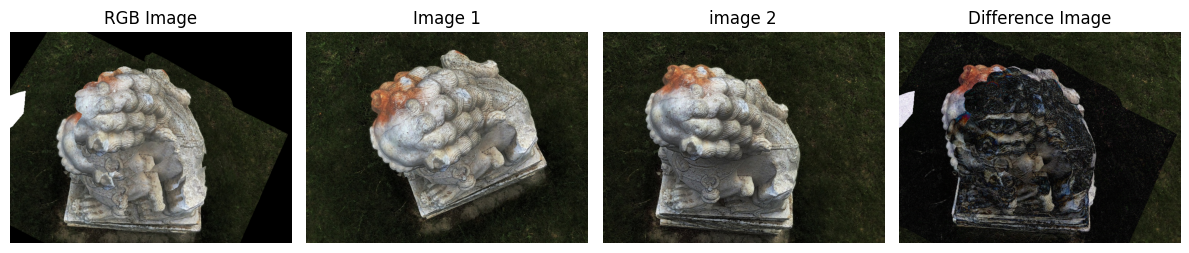

In [ ]:
import matplotlib.pyplot as plt
# 显示原图和差异图
plt.figure(figsize=(12, 8))

plt.subplot(1, 4, 1)
plt.title("RGB Image")
plt.imshow(rgb_array)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Image 1")
plt.imshow(img1_array)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("image 2")
plt.imshow(img2_array)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Difference Image")
plt.imshow(diff_array)
plt.axis('off')

plt.tight_layout()
plt.show()